<font size="+3"><strong>Autoregressive Models</strong></font>

In [1]:
__author__ = "Donald Ghazi"
__email__ = "donald@donaldghazi.com"
__website__ = "donaldghazi.com"

In [3]:
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px

from pymongo import MongoClient
from sklearn.metrics import mean_absolute_error
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.ar_model import AutoReg

warnings.simplefilter(action="ignore", category=FutureWarning)

Very similar to linear models. Same thing but a slightly different package. 

Goal - Create a autoregressive (AR) model to predict PM2.5 levels.

Machine Learning Workflow
1. Prepare Data
    - 1. Import
    - 2. Explore: ACF plot, PCAF plot
    - 3. Split
2. Build Model
    - 1. Baseline
    - 2. Iterate: AR model with statsmodel
    - 3. Evaluate: Walk-forward validation
3. Communicate Results
    - 1. Time series plot with plotly express.

# Prepare Data

## Import

In [4]:
# Create a client to connect to the MongoDB server that assigns the "air-quality" database to db, and the "nairobi" connection to nairobi

client = MongoClient(host="localhost", port=27017)
db = client["air-quality"]
nairobi = db["nairobi"]

In [5]:
# Change the wrangle function so that it returns a Series of the resampled data instead of a DataFrame

def wrangle(collection):
    results = collection.find(
        {"metadata.site": 29, "metadata.measurement": "P2"},
        projection={"P2": 1, "timestamp": 1, "_id": 0},
    )

    # Read data into DataFrame
    df = pd.DataFrame(list(results)).set_index("timestamp")

    # Localize timezone
    df.index = df.index.tz_localize("UTC").tz_convert("Africa/Nairobi")

    # Remove outliers
    df = df[df["P2"] < 500]

    # Resample to 1hr window
    y = df["P2"].resample("1H").mean().fillna(method='ffill')
    return y

In [6]:
# Use my wrangle function to read the data from the nairobi collection into the Series y
y = wrangle(nairobi)
y.head()

timestamp
2018-09-01 03:00:00+03:00    17.541667
2018-09-01 04:00:00+03:00    15.800000
2018-09-01 05:00:00+03:00    11.420000
2018-09-01 06:00:00+03:00    11.614167
2018-09-01 07:00:00+03:00    17.665000
Freq: H, Name: P2, dtype: float64

In [7]:
y.shape

(2928,)

## Explore

In [8]:
y.corr(y)

1.0

In [9]:
y.corr(y.shift(1))

0.6506785333937847

In [10]:
y.corr(y.shift(3))

0.31272080474576847

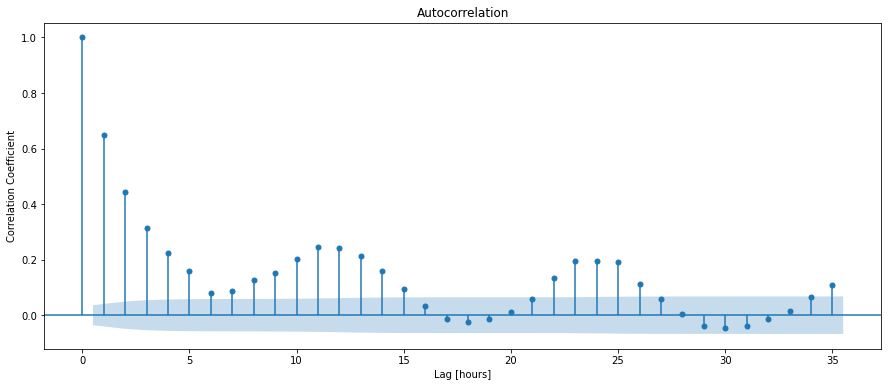

In [11]:
# Create an ACF plot for the data in y
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y, ax=ax) 
plt.xlabel("Lag [hours]")               # Label the x-axis as "Lag [hours]"
plt.ylabel("Correlation Coefficient");  # Label the y-axis as "Correlation Coefficient"

In [12]:
y.corr(y.shift(1))

0.6506785333937847

In [13]:
y.shift(1).corr(y.shift(2))

0.6506810900745511

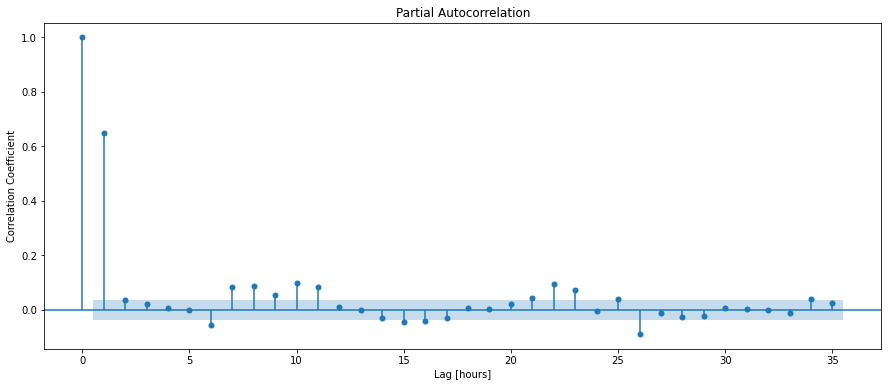

In [14]:
# Create an PACF plot for the data in y
fig, ax = plt.subplots(figsize=(15, 6))
plot_pacf(y, ax=ax)
plt.xlabel("Lag [hours]")               # Label the x-axis as "Lag [hours]"
plt.ylabel("Correlation Coefficient");  # Label the y-axis as "Correlation Coefficient"

## Split

In [15]:
cutoff_test = 

y_train =
y_test = 

SyntaxError: invalid syntax (4141578392.py, line 1)

In [ ]:
len(y)

In [ ]:
int(len(y) * 0.95)

In [ ]:
# Split y into training and test sets 

cutoff_test = int(len(y) * 0.95)      
y_train = y.iloc[:cutoff_test]         # The first 95% of the data should be in my training set
y_test = y.iloc[cutoff_test:]          # The remaining 5% should be in the test set

In [ ]:
len(y_train) + len(y_test)

In [ ]:
len(y_train) + len(y_test) == len(y)

# Build Model

## Baseline

In [ ]:
# Calculate the baseline mean absolute error for my model
y_train_mean = y_train.mean()
y_pred_baseline = [y_train_mean] * len(y_train)
mae_baseline = mean_absolute_error(y_train, y_pred_baseline)

print("Mean P2 Reading:", round(y_train_mean, 2))
print("Baseline MAE:", round(mae_baseline, 2))

## Iterate

In [ ]:
# Instantiate an AutoReg model and fit it to the training data y_train
model = AutoReg(y_train, lags=26).fit()  # Be sure to set the lags argument to 26

In [ ]:
model.predict()

In [ ]:
model.predict().isnull().sum()

In [ ]:
# Generate a list of training predictions for my model and use them to calculate my training mean absolute error
y_pred = model.predict().dropna()
training_mae = mean_absolute_error(y_train.iloc[26:], y_pred)
print("Training MAE:", training_mae)

In [ ]:
# Use y_train and y_pred to calculate the residuals for my model
y_train_resid = y_train - y_pred
y_train_resid.tail()

In [ ]:
y_train_resid = model.resid
y_train_resid.tail()

In [ ]:
# Create a plot of y_train_resid
fig, ax = plt.subplots(figsize=(15, 6))
y_train_resid.plot(ylabel="Residual Value", ax=ax);

In [16]:
# Create a histogram of y_train_resid
y_train_resid.hist()
plt.xlabel("Residual Value")
plt.ylabel("Frequency")
plt.title("AR(26), Distribution of Residuals");

NameError: name 'y_train_resid' is not defined

In [ ]:
# Create an ACF plot of y_train_resid
fig, ax = plt.subplots(figsize=(15, 6))
plot_acf(y_train_resid, ax=ax);

## Evaluate

In [ ]:
y_test.head()

In [ ]:
y_test.tail()

In [ ]:
y_test.index.min()

In [ ]:
y_test.index.max()

In [17]:
# Calculate the test mean absolute error for my model
y_pred_test = model.predict(y_test.index.min(), y_test.index.max())
test_mae = mean_absolute_error(y_test, y_pred_test)
print("Test MAE:", test_mae)

NameError: name 'model' is not defined

In [18]:
# Create a DataFrame test_predictions that has two columns: "y_test" and "y_pred" & be sure the index of test_predictions matches the index of y_test

df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred": y_pred_test}, index=y_test.index # The first should contain the true values for my test set & the second should contain my model's predictions
)

NameError: name 'y_test' is not defined

In [19]:
# Create a time series plot for the values in test_predictions using plotly express
fig = px.line(df_pred_test, labels={"value": "P2"}) # Be sure that the y-axis is properly labeled as "P2"
fig.show()

NameError: name 'df_pred_test' is not defined

In [165]:
%%capture  # Perform walk-forward validation for my model for the entire test set y_test
y_pred_wfv = pd.Series()                   # Store my model's predictions in the Series y_pred_wfv
history = y_train.copy()
for i in range(len(y_test)):
    model = AutoReg(history, lags=26).fit()
    next_pred = model.forecast()
    y_pred_wfv = y_pred_wfv.append(next_pred)
    history = history.append(y_test[next_pred.index])

In [166]:
len(y_pred_wfv)

147

In [167]:
len(y_test)

147

In [168]:
history.tail(1)

timestamp
2019-01-01 02:00:00+03:00    18.803333
Freq: H, Name: P2, dtype: float64

In [169]:
y_test.head(1)

timestamp
2018-12-26 00:00:00+03:00    5.679091
Freq: H, Name: P2, dtype: float64

In [170]:
model = AutoReg(history, lags=26).fit()

In [171]:
model.forecast()

2019-01-01 03:00:00+03:00    14.110356
Freq: H, dtype: float64

In [172]:
# Calculate the test mean absolute error for my model
test_mae = mean_absolute_error(y_test, y_pred_wfv)
print("Test MAE (walk forward validation):", round(test_mae, 2))

Test MAE (walk forward validation): 1.4


# Communicate Results

In [173]:
# Print out the parameters for my trained model
print(model.params)

intercept    2.021763
P2.L1        0.587991
P2.L2        0.019749
P2.L3        0.023426
P2.L4        0.026807
P2.L5        0.044019
P2.L6       -0.101889
P2.L7        0.029814
P2.L8        0.049894
P2.L9       -0.017513
P2.L10       0.032585
P2.L11       0.064034
P2.L12       0.005978
P2.L13       0.018366
P2.L14      -0.007634
P2.L15      -0.016571
P2.L16      -0.015587
P2.L17      -0.035295
P2.L18       0.000929
P2.L19      -0.003956
P2.L20      -0.020668
P2.L21      -0.012730
P2.L22       0.052431
P2.L23       0.074405
P2.L24      -0.024263
P2.L25       0.090515
P2.L26      -0.088646
dtype: float64


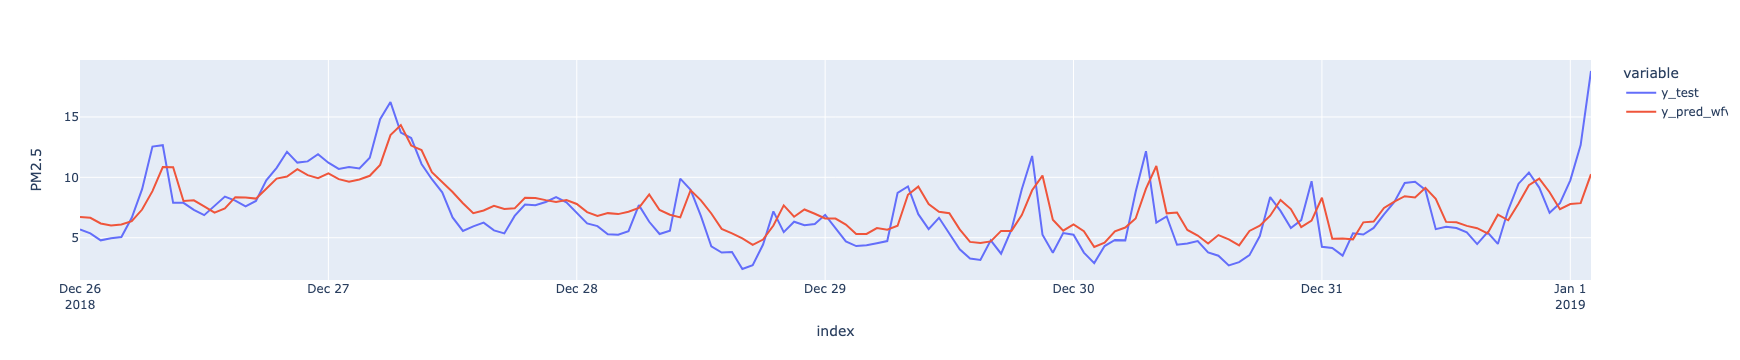

In [174]:
# Put the values for y_test and y_pred_wfv into the DataFrame df_pred_test

df_pred_test = pd.DataFrame(
    {"y_test": y_test, "y_pred_wfv": y_pred_wfv}
)
fig = px.line(df_pred_test, labels={"value": "PM2.5"}) # Plot df_pred_test using plotly express
fig.show()